<a href="https://colab.research.google.com/github/afdhald/ML-Genap-2425/blob/main/Praktikum3/NaiveBayesModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Main Types of Naive Bayes Classifier**

Terdapat tiga jenis utama pengklasifikasi Naive Bayes. Perbedaan utama antara ketiga jenis ini terletak pada asumsi yang dibuat tentang distribusi fitur:

*   **Bernoulli Naive Bayes**: Cocok untuk fitur biner/boolean. Diasumsikan setiap fitur adalah variabel bernilai biner (0/1).
*   **Multinomial Naive Bayes**: Biasanya digunakan untuk penghitungan diskret. Sering digunakan dalam klasifikasi teks, di mana fitur mungkin berupa penghitungan kata.
*   **Gaussian Naive Bayes**: Mengasumsikan bahwa fitur kontinu mengikuti distribusi normal.

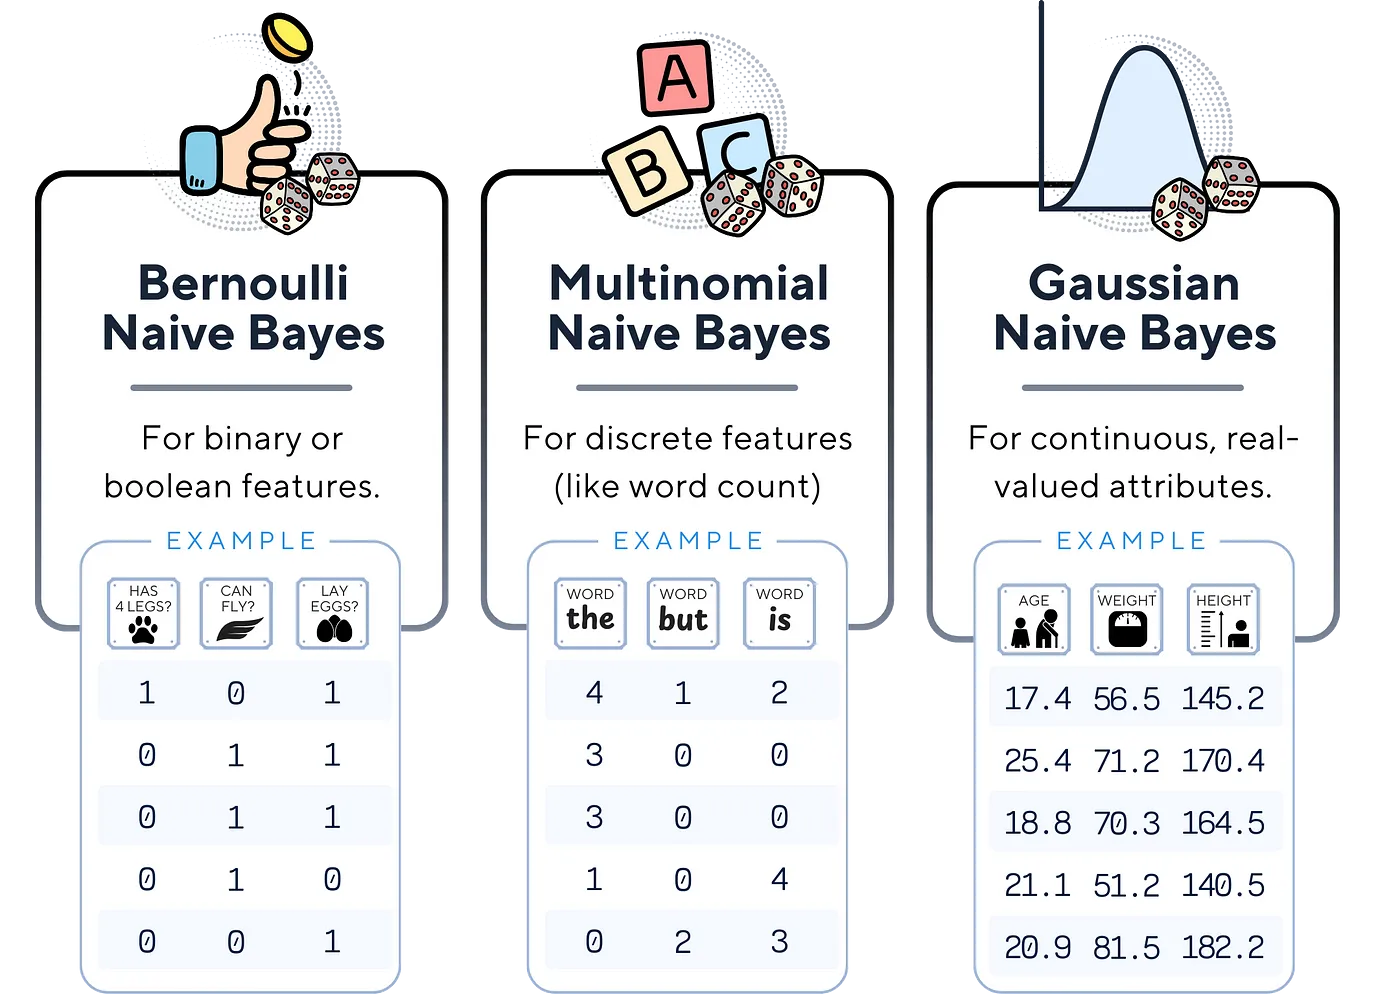
Source Image: https://miro.medium.com/v2/resize:fit:1400/format:webp/1*oBpcc5GIf6hcZoxNqpslqg.png

Bernoulli NB mengasumsikan data biner, Multinomial NB bekerja dengan hitungan diskrit, dan Gaussian NB menangani data kontinu dengan asumsi distribusi normal.


## **Bernoulli Naive Bayes**

Pada praktikum ini kita akan menggunakan data dummy yaitu golf dataset untuk melatih model Bernoulli Naive Bayes yang akan digunakan untuk memprediksi apakah seseorang akan bermain golf berdasarkan kondisi cuaca.

**Step 1. Import library yang diperlukan dan generate dummy dataset**

In [1]:
# Import needed libraries
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Load the dataset
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rainy', 'rainy', 'rainy', 'overcast', 'sunny', 'sunny', 'rainy', 'sunny', 'overcast', 'overcast', 'rainy', 'sunny', 'overcast', 'rainy', 'sunny', 'sunny', 'rainy', 'overcast', 'rainy', 'sunny', 'overcast', 'sunny', 'overcast', 'rainy', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, True, True, False, True, True, False, False, True, False, True, True, False, True, False, False, True, False, False],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes']
}
df = pd.DataFrame(dataset_dict)

df.head()

,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85.0,85.0,False,No
1,sunny,80.0,90.0,True,No
2,overcast,83.0,78.0,False,Yes
3,rainy,70.0,96.0,False,Yes
4,rainy,68.0,80.0,False,Yes


**Step 2. Data Preprocessing**

Karena semua fitur harus dalam format 0 dan 1, maka kita perlu mengkonversi nilai fitur yang ada saat ini ke dalam format biner.

*  Pertama kita akan mengkonversi fitur '**Outlook**' dengan menggunakan algoritma One-Hot Encoding (OHE) yang akan mengubah nilai kategori menjadi bentuk numerik biner. Kemudian, nilai dari fitur **Wind** dan kelas/label '**Play**' juga akan dikonversi dari boolean ke bentuk biner.

In [ ]:
# ONE-HOT ENCODE 'Outlook' COLUMN
df = pd.get_dummies(df, columns=['Outlook'],  prefix='', prefix_sep='', dtype=int)

# CONVERT 'Windy' (bool) and 'Play' (binary) COLUMNS TO BINARY INDICATORS
df['Wind'] = df['Wind'].astype(int)
df['Play'] = (df['Play'] == 'Yes').astype(int)

df.head()

,Temperature,Humidity,Wind,Play,overcast,rainy,sunny
0,85.0,85.0,0,0,0,0,1
1,80.0,90.0,1,0,0,0,1
2,83.0,78.0,0,1,1,0,0
3,70.0,96.0,0,1,0,1,0
4,68.0,80.0,0,1,0,1,0


*   Selanjutnya, karena masih ada fitur yang belum dalam format biner yaitunya Temperatur dan Humidity maka kita juga akan mengkonversi fitur tersebut ke dalam bentuk biner. Caranya adalah dengan membagi nilai Temperatur menjadi ≤ 80 dan > 80. Untuk nilai temperatur ≤ 80 kita artikan Warm, sedangkan > 80 adalah Hot. Kemudian kita gunakan One-hot encode untuk mengkonversi nilai/kategori tersebut menjadi bentuk biner, 1 mewakili temperatur Hot dan 0 mewakili temperatur Warm.
*  Hal yang sama juga dilakukan untuk fitur Humidity, nilai humidity dipisahkan menjadi ≤ 75 dan > 75. Nilai ≤ 75 dilabeli dengan Dry dan > 75 dilabeli dengan Humid. Saat dikonversi, nilai 1 akan mewakili Humid dan 0 mewakili Dry.

In [ ]:
# One-hot encode the categorized columns and drop them after
# Define categories for 'Temperature' and 'Humidity' for dataframe
df['Temperature'] = pd.cut(df['Temperature'], bins=[0, 80, 100], labels=['Warm', 'Hot'])
df['Humidity'] = pd.cut(df['Humidity'], bins=[0, 75, 100], labels=['Dry', 'Humid'])

# One-hot encode the categorized columns
one_hot_columns = pd.get_dummies(df[['Temperature', 'Humidity']], drop_first=True, dtype=int)

# Drop the categorized columns from df
df = df.drop(['Temperature', 'Humidity'], axis=1)

# Concatenate the one-hot encoded columns with the original DataFrames
df = pd.concat([one_hot_columns, df], axis=1)

df.head()

,Temperature_Hot,Humidity_Humid,Wind,Play,overcast,rainy,sunny
0,1,1,0,0,0,0,1
1,0,1,1,0,0,0,1
2,1,1,0,1,1,0,0
3,0,1,0,1,0,1,0
4,0,1,0,1,0,1,0


*   Bagi data menjadi data latih dan data uji

In [ ]:
# Split data into training and testing sets
X, y = df.drop(columns='Play'), df['Play']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=False)
# X_train.head()

### **Main Mechanism**

* Hitung probabilitas setiap kelas dalam data pelatihan.
* Untuk setiap fitur dan kelas, hitung probabilitas fitur tersebut bernilai 1 dan 0 berdasarkan kelasnya.
* Untuk data baru: Untuk setiap kelas, kalikan probabilitasnya dengan probabilitas setiap nilai fitur (0 atau 1) untuk kelas tersebut.
* Prediksi kelas dengan probabilitas hasil tertinggi.

## **Training Steps**

Proses pelatihan untuk Bernoulli Naive Bayes melibatkan perhitungan probabilitas dari data pelatihan:
1. **Class Probability Calculation**: Untuk setiap kelas, hitung probabilitasnya: (Jumlah kejadian di kelas ini) / (Jumlah total kejadian)


In [ ]:
from fractions import Fraction

def calc_target_prob(attr):
    total_counts = attr.value_counts().sum()
    prob_series = attr.value_counts().apply(lambda x: Fraction(x, total_counts).limit_denominator())
    return prob_series

print(calc_target_prob(y_train))

Play
1    11/19
0     8/19
Name: count, dtype: object


2. **Feature Probability Calculation**: Untuk setiap fitur dan setiap kelas, hitunglah:
  * (Jumlah kejadian di mana fitur adalah 0 di kelas ini) / (Jumlah kejadian di kelas ini)
  * (Jumlah kejadian di mana fitur adalah 1 di kelas ini) / (Jumlah kejadian di kelas ini)

In [ ]:
from fractions import Fraction

# def sort_attr_label(attr, lbl):
#     return (pd.concat([attr, lbl], axis=1)
#             .sort_values([attr.name, lbl.name])
#             .reset_index()
#             .rename(columns={'index': 'ID'})
#             .set_index('ID'))

def calc_feature_prob(attr, lbl):
    total_classes = lbl.value_counts()
    counts = pd.crosstab(attr, lbl)
    prob_df = counts.apply(lambda x: [Fraction(c, total_classes[x.name]).limit_denominator() for c in x])

    return prob_df

# print(sort_attr_label(y_train, X_train['sunny']))
# print(calc_feature_prob(X_train['sunny'], y_train))

In [ ]:
for col in X_train.columns:
  print(calc_feature_prob(X_train[col], y_train), "\n")

Play               0     1
Temperature_Hot           
0                5/8  9/11
1                3/8  2/11 

Play              0     1
Humidity_Humid           
0               1/4  4/11
1               3/4  7/11 

Play    0     1
Wind           
0     3/8  8/11
1     5/8  3/11 

Play      0     1
overcast         
0         1  6/11
1         0  5/11 

Play     0     1
rainy           
0      3/4  7/11
1      1/4  4/11 

Play     0     1
sunny           
0      1/4  9/11
1      3/4  2/11 



Pada sklearn, semua proses di atas diringkas dalam metode 'fit' ini:

**from sklearn.naive_bayes import BernoulliNB**

In [ ]:
# Train the model
nb_clf = BernoulliNB()
nb_clf.fit(X_train, y_train)

BernoulliNB()

Prediksi data uji dan cek akurasinya

In [ ]:
# Make predictions
y_pred = nb_clf.predict(X_test)

# Check accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.5555555555555556


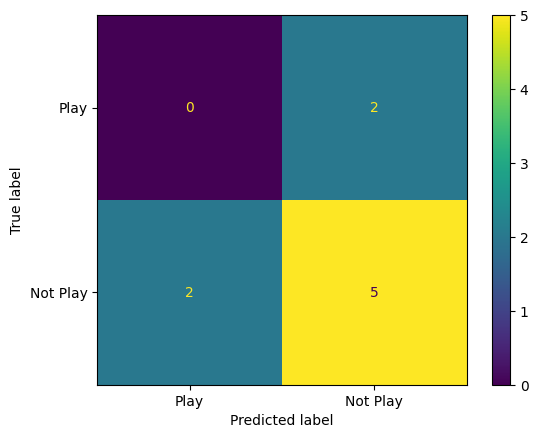

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)
labels = ["Play", "Not Play"]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();